(2) Ch4_Q14

In this problem, you will develop a model to predict whether a given car gets high or low gas mileage based on the Auto data set.***(a) Create a binary variable, mpg01, that contains a 1 if mpg contains a value above its median, and a 0 if mpg contains a value below its median. You can compute the median using the median() method of the data frame. Note you may find it helpful to add a column mpg01 to the data frame by assignment. Assuming you have stored the data frame as Auto, this can be done as follows:
Auto['mpg01'] = mpg01***

In [8]:
import pandas as pd
import numpy as np
from ISLP import load_data
pd.set_option('display.max_columns', None) 

In [30]:
Auto = load_data('Auto')
Auto.shape

(392, 8)

In [32]:
print("Original Auto DataFrame (first 5 rows):")
Auto.head()

Original Auto DataFrame (first 5 rows):


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [34]:
# --- 2. Compute the median of the 'mpg' column ---
mpg_median = Auto['mpg'].median()
print(f"Median of 'mpg' column: {mpg_median}\n")

# --- 3. Create the 'mpg01' binary variable ---
# Method 1: Using np.where (recommended for clarity and performance)
Auto['mpg01'] = np.where(Auto['mpg'] > mpg_median, 1, 0)

# Method 2: Using boolean comparison and .astype(int)
# Auto['mpg01'] = (Auto['mpg'] > mpg_median).astype(int)

# Method 3: Using a lambda function with .apply() (less efficient for large datasets)
# Auto['mpg01'] = Auto['mpg'].apply(lambda x: 1 if x > mpg_median else 0)

# --- 4. Display the updated DataFrame with the new 'mpg01' column ---
print("Auto DataFrame with 'mpg01' column (first 5 rows):")
Auto.head()

Median of 'mpg' column: 22.75

Auto DataFrame with 'mpg01' column (first 5 rows):


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
name,,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1,0
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1,0
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1,0
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1,0
ford torino,17.0,8,302.0,140,3449,10.5,70,1,0


In [36]:
print("\n--- Value Counts for mpg01 ---")
Auto['mpg01'].value_counts()


--- Value Counts for mpg01 ---


mpg01
0    196
1    196
Name: count, dtype: int64

In [38]:
print("\n--- Verify a few rows manually ---")
Auto[['mpg', 'mpg01']].head(10)


--- Verify a few rows manually ---


,mpg,mpg01
name,,
chevrolet chevelle malibu,18.0,0
buick skylark 320,15.0,0
plymouth satellite,18.0,0
amc rebel sst,16.0,0
ford torino,17.0,0
ford galaxie 500,15.0,0
chevrolet impala,14.0,0
plymouth fury iii,14.0,0
pontiac catalina,14.0,0


***(b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.***

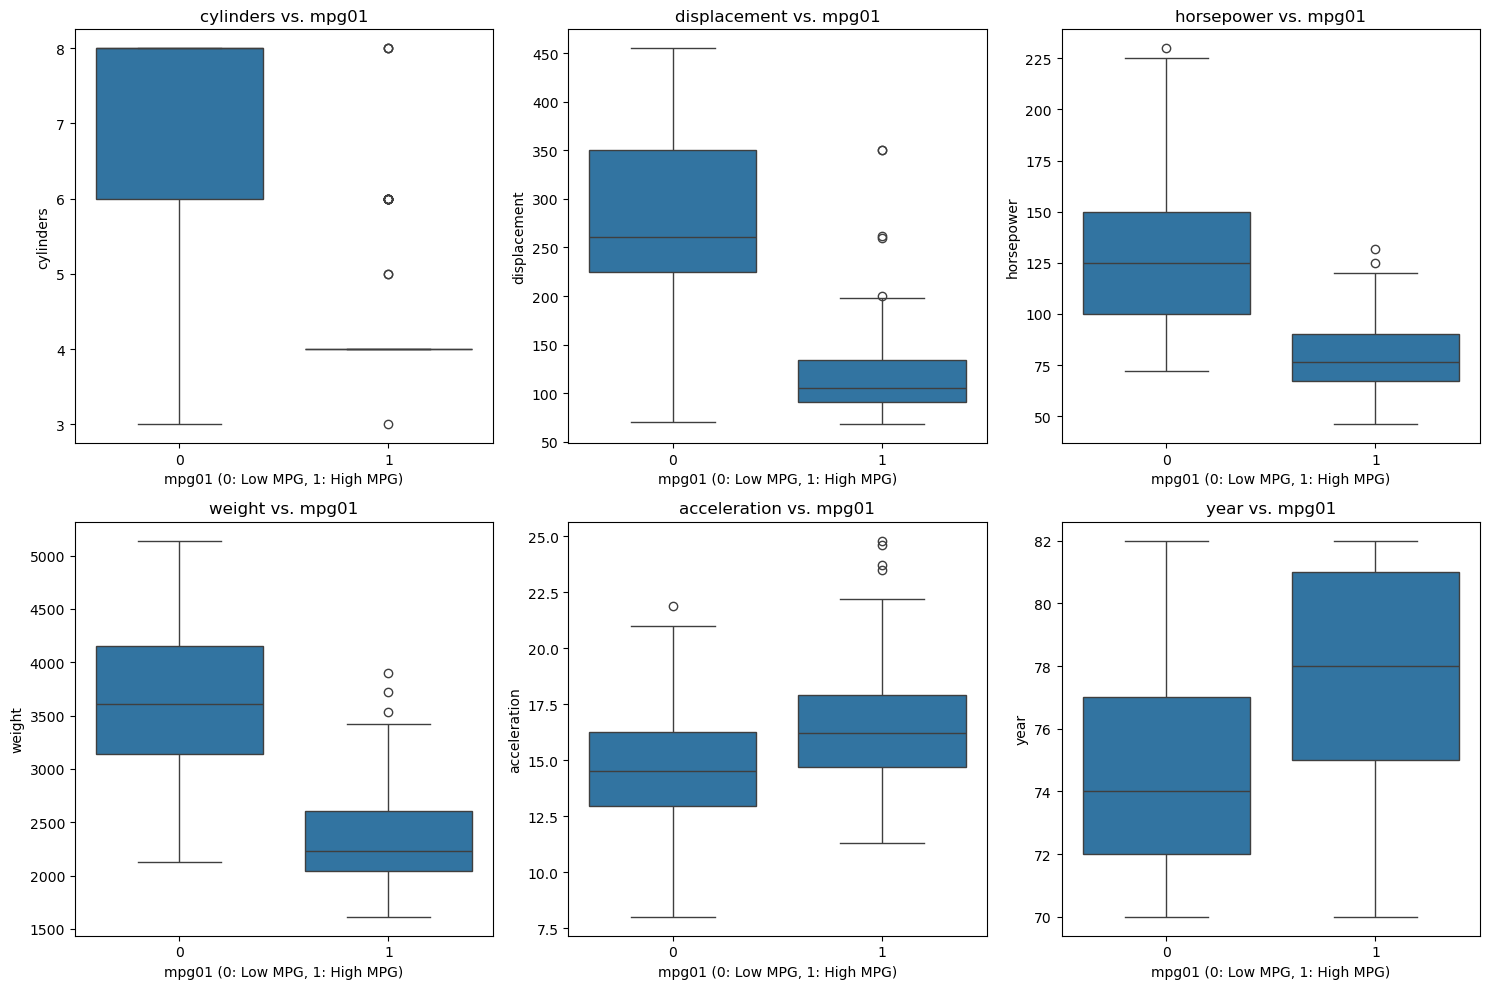

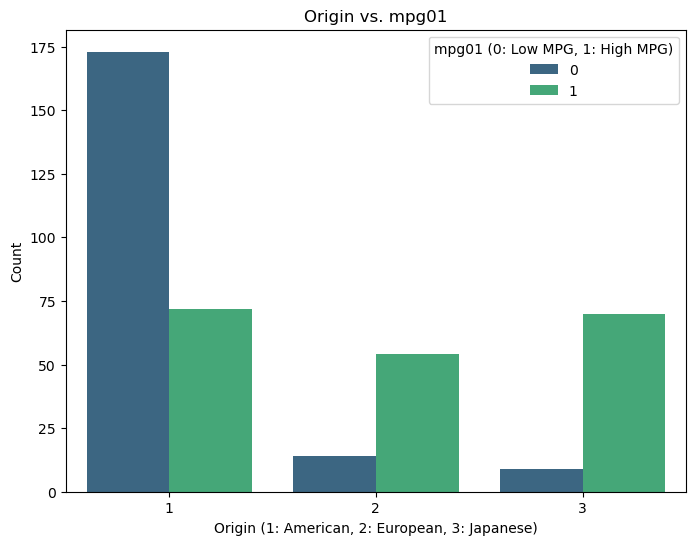

<Figure size 800x600 with 0 Axes>

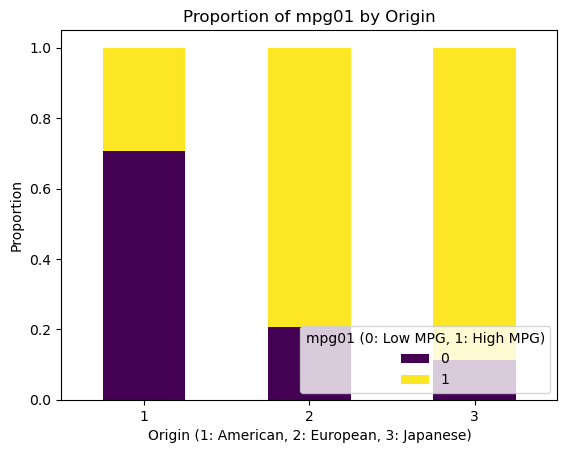

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
# --- 1. Box plots for numerical features vs. mpg01 ---
numerical_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns
    sns.boxplot(x='mpg01', y=feature, data=Auto)
    plt.title(f'{feature} vs. mpg01')
    plt.xlabel('mpg01 (0: Low MPG, 1: High MPG)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

# --- 2. Bar plot for categorical feature (origin) vs. mpg01 ---
plt.figure(figsize=(8, 6))
sns.countplot(x='origin', hue='mpg01', data=Auto, palette='viridis')
plt.title('Origin vs. mpg01')
plt.xlabel('Origin (1: American, 2: European, 3: Japanese)')
plt.ylabel('Count')
plt.legend(title='mpg01 (0: Low MPG, 1: High MPG)')
plt.show()

# You can also look at proportions for categorical features
plt.figure(figsize=(8, 6))
# Calculate proportions
origin_mpg01_props = Auto.groupby('origin')['mpg01'].value_counts(normalize=True).unstack()
origin_mpg01_props.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Proportion of mpg01 by Origin')
plt.xlabel('Origin (1: American, 2: European, 3: Japanese)')
plt.ylabel('Proportion')
plt.legend(title='mpg01 (0: Low MPG, 1: High MPG)', loc='lower right')
plt.xticks(rotation=0)
plt.show()

### 發現描述：

從箱形圖和條形圖中，我們可以觀察到 `mpg01` 與幾個特徵之間存在很強的關聯。

#### 最有可能在預測 `mpg01` 方面有用的特徵：

*   **`cylinders` (氣缸數)**：有非常清晰的分離。4 缸汽車幾乎都屬於高 `mpg01` (1)，而 8 缸汽車幾乎都屬於低 `mpg01` (0)。6 缸汽車則介於兩者之間，但傾向於低 `mpg01`。這是一個高度預測性的特徵。

*   **`displacement` (排氣量)**：高 `mpg01` (1) 的汽車通常比低 `mpg01` (0) 的汽車擁有顯著更低的引擎排氣量。箱形圖顯示了數據中心 50% (IQR) 的不同且不重疊的範圍。

*   **`horsepower` (馬力)**：與排氣量相似，高 `mpg01` (1) 的汽車通常馬力較低，而低 `mpg01` (0) 的汽車馬力較高。同樣，分佈情況也相當獨立。

*   **`weight` (車重)**：這個特徵也顯示出非常強的反向關係。較輕的汽車絕大多數與高 `mpg01` (1) 相關聯，而較重的汽車則與低 `mpg01` (0) 相關聯。中位數和整體分佈的差異非常大。

*   **`model_year` (車型年份)**：存在一個明顯的趨勢，即較新的汽車（`model_year` 接近 82）更有可能擁有高 `mpg01` (1)，而較舊的汽車（`model_year` 接近 70）則更多地與低 `mpg01` (0) 相關。這表明汽車製造隨著時間的推移變得更加節油。

*   **`origin` (產地)**：`origin` 的比例圖揭示了顯著差異：
    *   **產地 1 (美國)** 的汽車，其低 `mpg01` (0) 的比例遠高於高 `mpg01` (1)。
    *   **產地 2 (歐洲)** 和 **產地 3 (日本)** 的汽車則呈現相反情況；它們高 `mpg01` (1) 的比例遠高於低 `mpg01` (0)。
    這表明 `origin` 是一個強大的類別預測因子。

#### 關聯性較不顯著的特徵（但仍可能有用）：

*   **`acceleration` (加速度)**：`acceleration` 的箱形圖顯示 `mpg01=0` 和 `mpg01=1` 組之間存在一些重疊。高 `mpg01` (1) 的汽車往往具有略高（較慢）的加速時間（即圖上較高的值表示加速所需時間較長），這可能表示引擎較輕、動力較弱。然而，這種分離不像 `cylinders`、`displacement`、`horsepower` 或 `weight` 那樣明顯。

### 結論：

基於這次圖形探索，**`cylinders`、`displacement`、`horsepower`、`weight`、`model_year` 和 `origin`** 似乎是預測汽車油耗高低 (`mpg01`) 最有希望的特徵。它們在兩個 `mpg01` 類別中表現出清晰且獨特的模式。`acceleration` 也顯示出一些關聯，但組間重疊較多。

***(c) Split the data into a training set and a test set.***

In [53]:
from sklearn.model_selection import train_test_split
# --- Define features (X) and target (y) ---
# Drop 'mpg' (original continuous variable) and 'car_name' (identifier)
X = Auto.drop(['mpg', 'mpg01'], axis=1)
y = Auto['mpg01']

# --- Split the data ---
# test_size: The proportion of the dataset to include in the test split. Common values are 0.2 (20%) or 0.3 (30%).
# random_state: Ensures reproducibility. If you run the code again with the same random_state, you'll get the same split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Display the shapes of the resulting sets ---
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test:  {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test:  {y_test.shape}")

Shape of X_train: (274, 7)
Shape of X_test:  (118, 7)
Shape of y_train: (274,)
Shape of y_test:  (118,)


In [55]:
print("\n--- Example of y_train (first 5 rows) ---")
y_train.head()


--- Example of y_train (first 5 rows) ---


name
datsun 610              0
ford maverick           0
datsun 510 hatchback    1
amc gremlin             0
chevrolet nova          0
Name: mpg01, dtype: int64

In [57]:
print("\n--- Example of X_train (first 5 rows) ---")
X_train.head()


--- Example of X_train (first 5 rows) ---


,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,
datsun 610,4,108.0,94,2379,16.5,73,3
ford maverick,6,200.0,85,2587,16.0,70,1
datsun 510 hatchback,4,119.0,92,2434,15.0,80,3
amc gremlin,6,199.0,90,2648,15.0,70,1
chevrolet nova,6,250.0,100,3336,17.0,74,1


***(d) Perform LDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?***

In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Select the features identified in (b) ---
selected_features = ['cylinders', 'displacement', 'horsepower', 'weight', 'year', 'origin']
# 'acceleration' could also be included, but let's stick to the "most associated" ones first.

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# --- Preprocessing: One-hot encode 'origin' ---
# Define which columns are numerical and which are categorical
categorical_features = ['origin']
numerical_features = [col for col in selected_features if col not in categorical_features]

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ],
    remainder='drop' # Drop any columns not specified
)

# --- Create an LDA pipeline ---
# This ensures that preprocessing is applied consistently
lda_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('lda', LinearDiscriminantAnalysis())
])

# --- Train the LDA model on the training data ---
lda_pipeline.fit(X_train_selected, y_train)

# --- Make predictions on the test data ---
y_pred_lda = lda_pipeline.predict(X_test_selected)

# --- Calculate the test error ---
accuracy_lda = accuracy_score(y_test, y_pred_lda)
test_error_lda = 1 - accuracy_lda

print(f"Selected Features for LDA: {selected_features}")
print(f"LDA Test Accuracy: {accuracy_lda:.4f}")
print(f"LDA Test Error: {test_error_lda:.4f}")

Selected Features for LDA: ['cylinders', 'displacement', 'horsepower', 'weight', 'year', 'origin']
LDA Test Accuracy: 0.8559
LDA Test Error: 0.1441


***(e) Perform QDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?***

In [88]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis # Changed from LinearDiscriminantAnalysis

# --- Create a QDA pipeline ---
# This ensures that preprocessing is applied consistently
qda_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('qda', QuadraticDiscriminantAnalysis()) # Using QDA instead of LDA
])

# --- Train the QDA model on the training data ---
qda_pipeline.fit(X_train_selected, y_train)

# --- Make predictions on the test data ---
y_pred_qda = qda_pipeline.predict(X_test_selected)

# --- Calculate the test error ---
accuracy_qda = accuracy_score(y_test, y_pred_qda)
test_error_qda = 1 - accuracy_qda

print(f"Selected Features for QDA: {selected_features}")
print(f"QDA Test Accuracy: {accuracy_qda:.4f}")
print(f"QDA Test Error: {test_error_qda:.4f}")

Selected Features for QDA: ['cylinders', 'displacement', 'horsepower', 'weight', 'year', 'origin']
QDA Test Accuracy: 0.5763
QDA Test Error: 0.4237


/opt/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


***(f) Perform logistic regression on the training data in order to pre- dict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?***

In [94]:
from sklearn.linear_model import LogisticRegression # Changed to LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler # Added StandardScaler for numerical features

# --- Preprocessing: One-hot encode 'origin' and StandardScale numerical features ---
categorical_features = ['origin']
numerical_features = [col for col in selected_features if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features) # Added StandardScaler for numerical features
    ],
    remainder='drop'
)

# random_state for reproducibility of the solver if it's stochastic.
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# --- Train the Logistic Regression model on the training data ---
logistic_pipeline.fit(X_train_selected, y_train)

# --- Make predictions on the test data ---
y_pred_logistic = logistic_pipeline.predict(X_test_selected)

# --- Calculate the test error ---
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
test_error_logistic = 1 - accuracy_logistic

print(f"Selected Features for Logistic Regression: {selected_features}")
print(f"Logistic Regression Test Accuracy: {accuracy_logistic:.4f}")
print(f"Logistic Regression Test Error: {test_error_logistic:.4f}")

Selected Features for Logistic Regression: ['cylinders', 'displacement', 'horsepower', 'weight', 'year', 'origin']
Logistic Regression Test Accuracy: 0.8814
Logistic Regression Test Error: 0.1186


***(g) Perform naive Bayes on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?***

In [96]:
from sklearn.naive_bayes import GaussianNB # Changed to GaussianNB

# --- Preprocessing: One-hot encode 'origin' and pass numerical features directly ---
categorical_features = ['origin']
numerical_features = [col for col in selected_features if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features) # Pass numerical features as they are for GaussianNB
    ],
    remainder='drop' # Drop any columns not specified
)

# --- Create a Naive Bayes pipeline ---
naive_bayes_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB()) # Using Gaussian Naive Bayes
])

# --- Train the Naive Bayes model on the training data ---
naive_bayes_pipeline.fit(X_train_selected, y_train)

# --- Make predictions on the test data ---
y_pred_nb = naive_bayes_pipeline.predict(X_test_selected)

# --- Calculate the test error ---
accuracy_nb = accuracy_score(y_test, y_pred_nb)
test_error_nb = 1 - accuracy_nb

print(f"Selected Features for Naive Bayes: {selected_features}")
print(f"Naive Bayes Test Accuracy: {accuracy_nb:.4f}")
print(f"Naive Bayes Test Error: {test_error_nb:.4f}")

Selected Features for Naive Bayes: ['cylinders', 'displacement', 'horsepower', 'weight', 'year', 'origin']
Naive Bayes Test Accuracy: 0.8390
Naive Bayes Test Error: 0.1610


***(h) Perform KNN on the training data, with several values of K, in order to predict mpg01. Use only the variables that seemed most associated with mpg01 in (b). What test errors do you obtain? Which value of K seems to perform the best on this data set?***

Testing KNN with K from 1 to 15:
--------------------------------------------------
K =  1, Test Error: 0.1186
K =  2, Test Error: 0.1102
K =  3, Test Error: 0.1271
K =  4, Test Error: 0.1271
K =  5, Test Error: 0.1186
K =  6, Test Error: 0.1271
K =  7, Test Error: 0.1356
K =  8, Test Error: 0.1356
K =  9, Test Error: 0.1441
K = 10, Test Error: 0.1441
K = 11, Test Error: 0.1441
K = 12, Test Error: 0.1441
K = 13, Test Error: 0.1441
K = 14, Test Error: 0.1525
K = 15, Test Error: 0.1441
--------------------------------------------------
Best K: 2 with a Test Error of: 0.1102


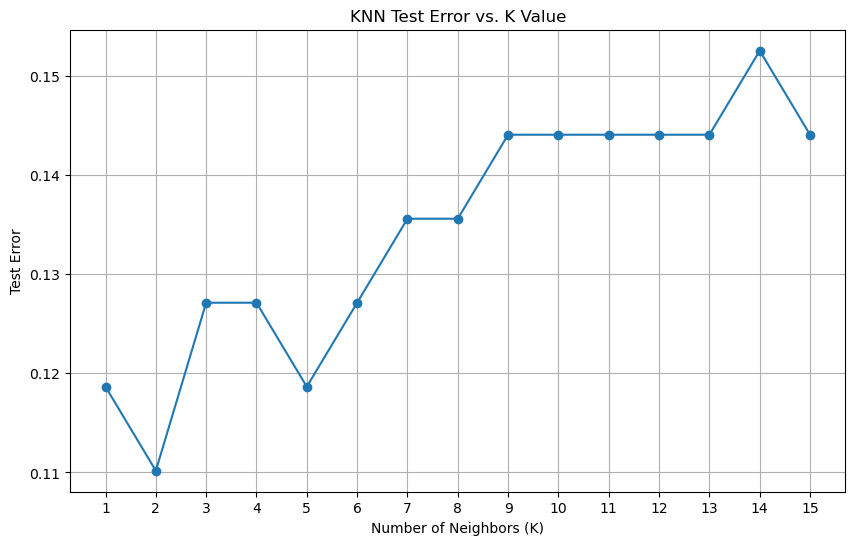

In [98]:
from sklearn.neighbors import KNeighborsClassifier # Changed to KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler # StandardScaler is crucial for KNN


# --- Preprocessing: One-hot encode 'origin' and StandardScale numerical features ---
categorical_features = ['origin']
numerical_features = [col for col in selected_features if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features) # StandardScaler is ESSENTIAL for KNN
    ],
    remainder='drop'
)

# --- Test various values of K ---
k_values = range(1, 16) # Testing K from 1 to 15
test_errors = []
best_k = -1
min_test_error = float('inf')

print(f"Testing KNN with K from {min(k_values)} to {max(k_values)}:")
print("--------------------------------------------------")

for k in k_values:
    # Create a KNN pipeline
    knn_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])

    # Train the KNN model on the training data
    knn_pipeline.fit(X_train_selected, y_train)

    # Make predictions on the test data
    y_pred_knn = knn_pipeline.predict(X_test_selected)

    # Calculate the test error
    accuracy_knn = accuracy_score(y_test, y_pred_knn)
    error_knn = 1 - accuracy_knn
    test_errors.append(error_knn)

    print(f"K = {k:2d}, Test Error: {error_knn:.4f}")

    if error_knn < min_test_error:
        min_test_error = error_knn
        best_k = k
    # If there's a tie, we might prefer smaller K for simplicity, or just keep the first one found.
    # For now, we'll keep the one that led to the minimum.

print("--------------------------------------------------")
print(f"Best K: {best_k} with a Test Error of: {min_test_error:.4f}")

# --- Optional: Visualize the test errors vs. K ---
plt.figure(figsize=(10, 6))
plt.plot(k_values, test_errors, marker='o', linestyle='-')
plt.title('KNN Test Error vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Error')
plt.xticks(k_values)
plt.grid(True)
plt.show()